In [1]:
import argparse
import io
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatialdata as sd
import scanpy as sc
import plotnine as gg
import os
from matplotlib.colors import rgb2hex

import scanpy as sc
import plotnine as gg
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.rcParams["svg.fonttype"] = "none"

adata_path = "/ewsc/pboyeau/data/guimaraes_2024_pancancer_single_cell/guimaraes_2024_pancancer_single_cell.h5ad"
adata = sc.read_h5ad(adata_path)
adata.var = adata.var.set_index("feature_name")
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()

adata_breast = adata[adata.obs["tissue"] == "breast"].copy()
adata_breast_select = adata_breast[adata_breast.obs["cell_type"].isin(["mononuclear phagocyte", "epithelial cell", "neutrophil"])].copy()
adata_breast_select_monocytes = adata_breast[adata_breast.obs["cell_type"] == "mononuclear phagocyte"].copy()


/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/anndata/_core/anndata.py:803: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM']

    Inferred to be: categorical



# Plots

### imports

In [39]:
sdata = sd.read_zarr("/ewsc/pboyeau/data/csde_revision/breast_cancer/region_R2_annotated.zarr")
adata = sdata["table"]
adata = adata[adata.obs["cell_type"].notna()].copy()

annotation_dir = "/ewsc/pboyeau/data/csde_revision/breast_cancer/annotations_macrophages"
results_dir = "/ewsc/pboyeau/projects/csde_experiments_revision/results/breast_cancer"
images_dir = annotation_dir + "/images"
with open(annotation_dir + "/config.json") as f:
    cfg = json.load(f)

os.makedirs(results_dir, exist_ok=True)

adata.obs["is_in_tumor"] = adata.obs["is_in_tumor"].astype(str)

In [44]:
for g in adata.var.index:
    print(g)

PDK4
DVL2
CX3CL1
CD79B
PGLYRP1
CD4
SNAI2
TNFRSF17
TLL1
ICAM3
TRIP13
KRT14
TBX21
FAP
NFKB2
CCN5
CEACAM6
LAG3
ESR1
KRT23
CDC6
TPSD1
TGFBR3
MMP11
IL2RB
CTSG
GZMH
GZMB
NFKBIA
PSME2
PROCR
MYBL2
TLR8
MMP2
CORO1A
TGFB1
CD79A
NKG7
CADM4
HGF
TFPI2
HOXA5
SERPINE1
DNAJC12
CSF3
WNT3
CCL2
CD38
IL2
CD82
CCND1
CD69
CDKN1B
IFNG
KLRB1
LOX
GZMK
IL12B
LTF
MLH1
RBP1
HES1
IL18R1
PRTN3
BCL9
SELL
ABCG2
TGFB3
HOXB7
DUSP1
EGR1
TBX2
KLRK1
TNFSF10
CXCR4
RAMP3
TWIST1
LRP1
PLCG1
SNAI1
CDKN1A
SOX9
TNFSF9
CD70
FFAR2
CCR7
KLF2
FGL2
LIF
SMO
DLL4
AMOTL2
ACKR4
CMA1
FOXA1
EGLN3
DSC2
RAF1
ELN
KRT5
KRT6B
PLVAP
BST2
RAMP2
KRT15
SDC1
LGR6
LYVE1
CCNB1
PDGFRA
APC
TBX3
NT5E
EHF
CDK4
THSD1
BRIP1
BLK
GYPC
CCL21
FGFBP2
TLR2
SORL1
MMP7
BARD1
CCND2
LYZ
LRP6
VWF
PROX1
TNFRSF13B
CDH1
PDGFRB
FLT4
TSPAN13
RBL2
CREBBP
TYROBP
CCNE1
PRKX
UCP1
IL1B
BRD4
CD44
BIRC3
ELANE
LY75
SELP
EPCAM
GNLY
KDR
STK17B
PIK3CA
MCAM
LAMC2
MCM6
CD80
YWHAE
FGF2
STAT3
FOSL2
MMRN1
ICAM1
PPARGC1A
SEL1L3
ZAP70
MCM2
MSH3
EGF
GABRP
STAP1
NBN
WNT2
LAMP3
CHKA
CDK6
LZTS1

In [ ]:
from csde import prepare_csde_inputs

_prep = prepare_csde_inputs(
    annotation_dir=annotation_dir,
    spatial_group_target="in_tumor",
    spatial_group_reference="out_of_tumor",
)
adata_gt = _prep["adata_gt"]

### UMAP

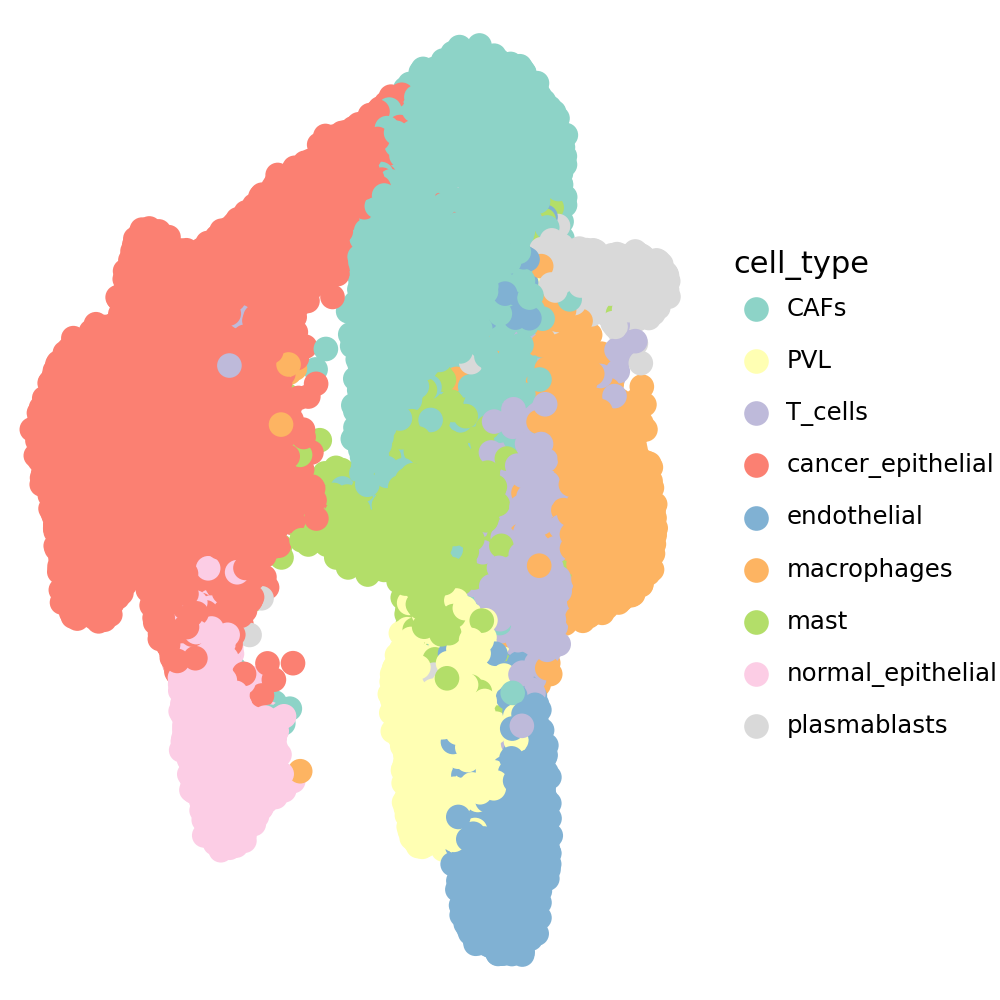

In [9]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
adata.obs.loc[:, "UMAP1"] = adata.obsm["X_umap"][:, 0]
adata.obs.loc[:, "UMAP2"] = adata.obsm["X_umap"][:, 1]

fig = (
    gg.ggplot(adata.obs, gg.aes(x="UMAP1", y="UMAP2", color="cell_type"))
    + gg.geom_point(stroke=0.0, size=5)
    + gg.theme_void()
    + gg.theme(
        # legend_position="none",
        figure_size=(5, 5),
    )
    + gg.scale_color_brewer(type="qual", palette="Set3")
)
# fig.save(results_dir + "/breast_cancer_UMAP_cell_types.png", dpi=500, transparent=True)
fig

### Location

In [10]:
cmap = {
    "False": "#BFC0D3",
    "True": "#5A5B69",
}

fig = (
    gg.ggplot(
        adata.obs, gg.aes(x="center_x", y="center_y", color="is_in_tumor")
    )
    + gg.geom_point(stroke=0.0, size=0.8)
    + gg.geom_point(
        gg.aes(x="center_x", y="center_y"),
        data=adata.obs.query("cell_type == 'macrophages'"),
        size=0.8,
        stroke=0.0,
        # alpha=0.8,
        inherit_aes=False,
        color="red",
    )
    + gg.theme_void()
    + gg.scale_color_manual(values=cmap)
    + gg.coord_cartesian()
    + gg.theme(
        legend_position="none",
        dpi=1500,
    )
)
fig.save(results_dir + "/macrophages_location.png", dpi=1500)

/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /ewsc/pboyeau/projects/csde_experiments_revision/results/breast_cancer/macrophages_location.png


### RNA contamination

In [3]:
from csde.spatial_utils import plot_region

def plot_cell(cell_id, gene_colors, delta=50.0, image_channel="DAPI", figsize=(7, 7)):
    obs = adata.obs.loc[cell_id]
    cx, cy = float(obs["center_x"]), float(obs["center_y"])
    ax = plot_region(
        sdata,
        xmin=cx - delta, xmax=cx + delta,
        ymin=cy - delta, ymax=cy + delta,
        gene_colors=gene_colors,
        image_channel=image_channel,
        coord_system="micron",
        figsize=figsize,
    )
    ax.set_title(f"{obs['cell_type']}  |  {cell_id}", fontsize=8)
    return ax

In [7]:
gene_colors = {
    "EPHB3":  "#e41a1c",  # red
    "CD68":   "#74c476",  # light green  — pan-macrophage
    "CD163":  "#31a354",  # medium green — M2/tumor-associated
    "CSF1R":  "#006d2c",  # dark green   — myeloid lineage
}

In [9]:
adata_gt.obs["annotation"]

EntityID
3717117100001100177    2
3717117100002100410    2
3717117100003100158    2
3717117100003100291    0
3717117100003100331    2
                      ..
3717117100069100534    0
3717117100069100545    2
3717117100069100669    2
3717117100069100680    2
3717117100069200334    1
Name: annotation, Length: 600, dtype: int64

In [11]:
adata_gt_macrophages = adata_gt[adata_gt.obs["annotation"] <= 1].copy()
adata_gt_macrophages

AnnData object with n_obs × n_vars = 146 × 296
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'Cellbound2_raw', 'Cellbound2_high_pass', 'Cellbound3_raw', 'Cellbound3_high_pass', 'Cellbound1_raw', 'Cellbound1_high_pass', 'region', 'slide', 'dataset_id', 'cells_region', 'EntityID', 'leiden_1', 'leiden_2', 'cell_type', 'is_tumor', 'is_in_tumor', 'spatial_group', 'prediction', 'is_correct', 'annotation', 'sampling_weight'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'blank'

In [12]:
adata_gt_macrophages.obs.loc[:, "EPHB3"] = adata_gt_macrophages[:, "EPHB3"].X.toarray().flatten()

In [13]:
adata_gt_macrophages.obs["EPHB3"].sort_values(ascending=False)

EntityID
3717117100017100471    3
3717117100022100230    2
3717117100018100783    1
3717117100046101319    1
3717117100061100614    1
                      ..
3717117100068101243    0
3717117100069100298    0
3717117100069100496    0
3717117100069100534    0
3717117100069200334    0
Name: EPHB3, Length: 146, dtype: int64

In [ ]:
def clean_ax(ax):
      ax.axis("off")
      ax.set_title("")
      fig = ax.figure
      for a in fig.axes:
          if a is not ax:
              a.remove()
      fig.tight_layout(pad=0)
      return fig


In [24]:
obs_names = [
    "3717117100017100471",
    "3717117100022100230",
    "3717117100018100783",
    "3717117100046101319",
    "3717117100061100614",

]

for obs_name in obs_names:
    ax = plot_cell(obs_name, gene_colors=gene_colors, delta=50.0, image_channel="DAPI", figsize=(7, 7))
    fig = clean_ax(ax)
    fig.savefig(f"{results_dir}/{obs_name}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1017: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/tmp/ipykernel_1180389/1866011983.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points,

### dotplots

In [ ]:
fig = sc.pl.dotplot(
    adata_breast_select,
    var_names=["CSF3R", "EPHB3"],
    groupby="cell_type",
    use_raw=False,
    return_fig=True,
    show=True
)
fig.savefig("dotplot_ESR1_EPHB3.svg", bbox_inches="tight")

In [25]:
adata_breast.X[0].max()

np.float64(5.712491540178978)

In [ ]:
from scipy import stats 
import pandas as pd

genes = ["ESR1", "EPHB3"]

mono = adata_breast_select[adata_breast_select.obs["cell_type"] == "mononuclear phagocyte"]
epi  = adata_breast_select[adata_breast_select.obs["cell_type"] == "epithelial cell"]

results = []
for gene in genes:
    mono_expr = mono[:, gene].X.toarray().ravel()
    epi_expr  = epi[:, gene].X.toarray().ravel()

    # 1. one-sample t-test: mean == 0 in mononuclear phagocytes
    t1, p1 = stats.ttest_1samp(mono_expr, popmean=0)

    # 2. two-sample t-test: epithelial vs mononuclear phagocytes
    t2, p2 = stats.ttest_ind(epi_expr, mono_expr)

    results.append({
        "gene": gene,
        "mono_mean": mono_expr.mean(),
        "epi_mean": epi_expr.mean(),
        "ttest_mono_vs0_stat": t1, "ttest_mono_vs0_pval": p1,
        "ttest_epi_vs_mono_stat": t2, "ttest_epi_vs_mono_pval": p2,
    })

pd.DataFrame(results)

### discovery comparison

In [13]:
from scipy import sparse
from statsmodels.discrete.discrete_model import Poisson
from statsmodels.stats.multitest import multipletests

results_classic = pd.read_csv("/ewsc/pboyeau/data/csde_revision/results/breast_cancer/classic_poisson_results.csv")
results_csde = pd.read_csv("/ewsc/pboyeau/data/csde_revision/results/breast_cancer/csde_results.csv")


def poisson_glm_comparison(adata, group_key):
    """Poisson GLM DE: compare each gene between group 1 vs 0 in group_key.

    BH correction is computed over exactly the genes in ``adata``, so the FDR
    universe equals the gene support passed in.
    """
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()
    X = X.astype(float)

    group = adata.obs[group_key].values.astype(float)
    design = np.column_stack([np.ones(len(group)), group])  # intercept + condition

    gene_names = adata.var_names
    results = []
    for i in range(X.shape[1]):
        y = X[:, i]
        try:
            fit = Poisson(y, design).fit(disp=False, method="bfgs", maxiter=200)
            lfc, pval = fit.params[1] / np.log(2), fit.pvalues[1]
        except Exception:
            lfc, pval = np.nan, np.nan
        results.append((gene_names[i], lfc, pval))

    df = pd.DataFrame(results, columns=["gene_name", "lfc", "pval"])
    valid = df["pval"].notna()
    padj = np.full(len(df), np.nan)
    if valid.sum() > 0:
        padj[valid] = multipletests(df.loc[valid, "pval"], method="fdr_bh")[1]
    df["padj"] = padj
    return df.assign(abs_lfc=lambda d: d["lfc"].abs())


# Macrophages with raw counts (rebuilt from sdata; `adata` is reused elsewhere)
adata_mac = sdata["table"]
adata_mac = adata_mac[adata_mac.obs["cell_type"] == "macrophages"].copy()
adata_mac.obs["is_in_tumor"] = (adata_mac.obs["is_in_tumor"].astype(str) == "True").astype(float)

# Gene support for the automated (imputation) approach:
#   "csde"      -> automated restricted to CSDE's gene set (shared FDR universe; "inner")
#   "automated" -> automated on its own gene set, genes expressed in >=10 macrophages ("outer")
AUTOMATED_GENE_SUPPORT = "csde"

if AUTOMATED_GENE_SUPPORT == "csde":
    support_genes = results_csde["gene_name"]
elif AUTOMATED_GENE_SUPPORT == "automated":
    n_exp = np.asarray((adata_mac.X > 0).sum(0)).ravel()
    support_genes = pd.Series(adata_mac.var_names[n_exp >= 10])
else:
    raise ValueError(AUTOMATED_GENE_SUPPORT)

adata_mac_support = adata_mac[:, adata_mac.var_names.isin(support_genes)].copy()
results_imputation = poisson_glm_comparison(adata_mac_support, "is_in_tumor")
print(f"automated gene support: {AUTOMATED_GENE_SUPPORT} ({len(results_imputation)} genes)")

automated gene support: csde (296 genes)


In [14]:
(results_imputation["padj"] <= 0.05).sum()

np.int64(201)

In [15]:
adata_path = "/ewsc/pboyeau/data/guimaraes_2024_pancancer_single_cell/guimaraes_2024_pancancer_single_cell.h5ad"
adata = sc.read_h5ad(adata_path)
adata.var = adata.var.set_index("feature_name")
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()

adata_breast = adata[adata.obs["tissue"] == "breast"].copy()
adata_breast_select = adata_breast[adata_breast.obs["cell_type"].isin(["mononuclear phagocyte", "epithelial cell", "neutrophil"])].copy()
adata_breast_select_monocytes = adata_breast[adata_breast.obs["cell_type"] == "mononuclear phagocyte"].copy()

/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/anndata/_core/anndata.py:803: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM']

    Inferred to be: categorical



In [16]:

# Discovery comparison — setup
from matplotlib_venn import venn3

PADJ_THRESHOLD = 0.1

MODEL_COLORS_BC = {
    "imput.":  "#FDBF64",
    "CSDE":    "#7EB8FF",
    "classic": "#90D989",
}

LEGEND = gg.theme_classic() + gg.theme(
    axis_text=gg.element_text(size=6),
    axis_title=gg.element_text(size=6.5),
    axis_line=gg.element_line(linewidth=0.35),
    legend_position="none",
    axis_ticks_major=gg.element_line(linewidth=0.25),
)

# Shared gene set across all three methods
shared_genes = (
    set(results_classic["gene_name"])
    & set(results_csde["gene_name"])
    & set(results_imputation["gene_name"])
)
print(f"classic={len(results_classic)}, CSDE={len(results_csde)}, imputation={len(results_imputation)}, shared={len(shared_genes)}")


classic=296, CSDE=296, imputation=296, shared=296


/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 1.5 x 1.08 in image.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./breast_cancer_ndiscoveries.svg


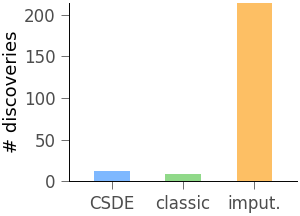

In [37]:

# Figure 1: barplot — # discoveries (padj < PADJ_THRESHOLD), all genes per method
_disc_counts = pd.DataFrame([
    {"method": "classic", "n_discoveries": (results_classic["padj"] < PADJ_THRESHOLD).sum()},
    {"method": "CSDE",    "n_discoveries": (results_csde["padj"] < PADJ_THRESHOLD).sum()},
    {"method": "imput.",  "n_discoveries": (results_imputation["padj"] < PADJ_THRESHOLD).sum()},
])

fig_ndiscoveries = (
    gg.ggplot(_disc_counts, gg.aes(x="method", y="n_discoveries", fill="method"))
    + gg.geom_col(width=0.5)
    + LEGEND
    + gg.theme(figure_size=(1.5, 1.08))
    + gg.scale_y_continuous(expand=(0, 0))
    + gg.scale_fill_manual(values=MODEL_COLORS_BC)
    + gg.labs(x="", y="# discoveries")
)
fig_ndiscoveries.save("./breast_cancer_ndiscoveries.svg", bbox_inches="tight")
fig_ndiscoveries


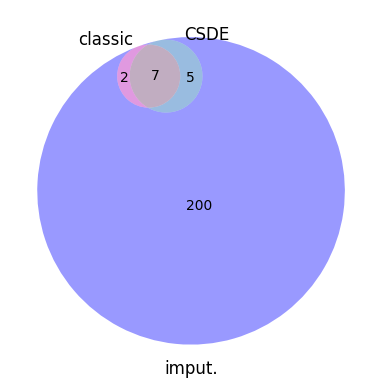

In [18]:

# Figure 2: Venn diagram — discoveries on shared gene set (padj < PADJ_THRESHOLD)
def _de_set(df):
    return set(df.loc[df["gene_name"].isin(shared_genes)].query(f"padj < {PADJ_THRESHOLD}")["gene_name"])

_set_classic = _de_set(results_classic)
_set_csde    = _de_set(results_csde)
_set_imput   = _de_set(results_imputation)

fig_venn, ax = plt.subplots(figsize=(4, 4))
venn3([_set_classic, _set_csde, _set_imput], set_labels=("classic", "CSDE", "imput."), ax=ax)
fig_venn.tight_layout()
fig_venn.savefig("./breast_cancer_venn.svg", bbox_inches="tight")
plt.show()


In [32]:
import scipy.stats as stats

_adata_ref = adata_breast.copy()

_effect_col = {"classic": "beta", "CSDE": "beta", "imput.": "lfc"}
_method_results = {
    "classic": results_classic,
    "CSDE": results_csde,
    "imput.": results_imputation,
}

# inner intersection of genes across all methods
_method_genes = pd.concat(
    {m: _df.set_index("gene_name")[_effect_col[m]].abs() for m, _df in _method_results.items()},
    axis=1,
    join='inner',
)

# further restrict to genes actually in adata_breast
_shared_genes = [g for g in _method_genes.index if g in _adata_ref.var_names]
_method_genes = _method_genes.loc[_shared_genes]
_adata_ref = _adata_ref[:, _shared_genes]

sc.tl.rank_genes_groups(
    _adata_ref,
    groupby="cell_type",
    groups=["mononuclear phagocyte"],
    reference="rest",
    method="wilcoxon",
    use_raw=False,
)
_ref_de = sc.get.rank_genes_groups_df(_adata_ref, group="mononuclear phagocyte")
ref_lfc = _ref_de.set_index("names")["logfoldchanges"]

# all genes are already shared; ref_lfc covers exactly _shared_genes
_method_genes["ref_lfc"] = ref_lfc.reindex(_method_genes.index)
merged = _method_genes.dropna()

_rows = []
for _method in _method_results:
    _rho, _p = stats.pearsonr(merged[_method], merged["ref_lfc"])
    _rows.append({
        "method": _method,
        "plausibility_score": _rho,
        "pval": _p,
        "n_genes": len(merged),
    })

plausibility = pd.DataFrame(_rows)
plausibility

/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:680: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


,method,plausibility_score,pval,n_genes
0,classic,-0.067419,0.251612,291
1,CSDE,0.069657,0.236183,291
2,imput.,-0.190604,0.001085,291


In [33]:
_adata_ref.var

,feature_is_filtered,feature_reference,feature_biotype,feature_length,feature_type
feature_name,,,,,
PDK4,False,NCBITaxon:9606,gene,691,protein_coding
CD4,False,NCBITaxon:9606,gene,600,protein_coding
ICAM3,False,NCBITaxon:9606,gene,911,protein_coding
NFKB2,False,NCBITaxon:9606,gene,844,protein_coding
CCN5,False,NCBITaxon:9606,gene,1559,protein_coding
...,...,...,...,...,...
CAMK1D,False,NCBITaxon:9606,gene,1578,protein_coding
PHF6,False,NCBITaxon:9606,gene,4432,protein_coding
TCF4,False,NCBITaxon:9606,gene,1004,protein_coding


### reproducibility score

In [34]:
_DATA_RESULTS_DIR = "/ewsc/pboyeau/data/csde_revision/results/breast_cancer"
results_classic_rep    = pd.read_csv(f"{_DATA_RESULTS_DIR}/classic_poisson_results_replicate.csv")
results_csde_rep       = pd.read_csv(f"{_DATA_RESULTS_DIR}/csde_results_replicate.csv")
results_imputation_rep = pd.read_csv(f"{_DATA_RESULTS_DIR}/imputation_poisson_results_replicate.csv")

In [35]:
_rep_results = {
    "classic": results_classic_rep,
    "CSDE":    results_csde_rep,
    "imput.":  results_imputation_rep,
}

_rows = []
for _method in _method_results:
    col = _effect_col[_method]
    main_s = _method_results[_method].set_index("gene_name")[col]
    rep_s  = _rep_results[_method].set_index("gene_name")[col]
    shared_g = main_s.index.intersection(rep_s.index)
    _rho, _p = stats.pearsonr(main_s.loc[shared_g], rep_s.loc[shared_g])
    _rows.append({"method": _method, "reproducibility_score": _rho, "pval": _p, "n_genes": len(shared_g)})

reproducibility = pd.DataFrame(_rows)
reproducibility

,method,reproducibility_score,pval,n_genes
0,classic,0.201118,9.941131e-04,265
1,CSDE,0.191884,1.700489e-03,265
2,imput.,0.562436,1.659335e-23,265


### Scatter plot

/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 2.5 x 2.0 in image.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /ewsc/pboyeau/projects/csde_experiments_revision/results/breast_cancer/breast_cancer_scatter_scores.svg


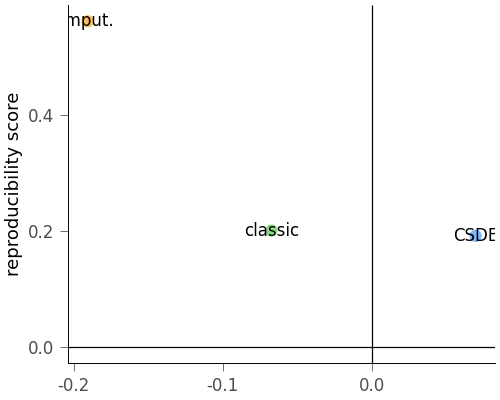

In [36]:
corrs_ = (
    plausibility[["method", "plausibility_score"]]
    .rename(columns={"method": "name_display", "plausibility_score": "bio. consistency score"})
    .merge(
        reproducibility[["method", "reproducibility_score"]].rename(
            columns={"method": "name_display", "reproducibility_score": "reproducibility score"}
        ),
        on="name_display",
    )
)

fig_scatter = (
    gg.ggplot(
        corrs_,
        gg.aes(x="bio. consistency score", y="reproducibility score", fill="name_display"),
    )
    + gg.geom_point(stroke=0.0, size=2.5)
    + gg.geom_text(gg.aes(label="name_display"), size=6)
    + gg.geom_hline(yintercept=0, color="black", size=0.25)
    + gg.geom_vline(xintercept=0, color="black", size=0.25)
    + LEGEND
    + gg.theme(figure_size=(2.5, 2.0))
    + gg.scale_fill_manual(values=MODEL_COLORS_BC)
    + gg.labs(x="")
)
fig_scatter.save(f"{results_dir}/breast_cancer_scatter_scores.svg", bbox_inches="tight")
fig_scatter

In [33]:
# Top 20 discoveries of the automated (imputation) approach, by |LFC| among
# significant genes (padj <= 0.05).
top20_imputation = (
    results_imputation.query("padj <= 0.05")
    .sort_values("abs_lfc", ascending=False)
    .head(20)
    .loc[:, ["gene_name", "lfc", "padj"]]
    .reset_index(drop=True)
)
top20_imputation.index += 1  # rank starting at 1
print(top20_imputation.to_string())
top20_imputation


   gene_name       lfc           padj
1      GATA3  3.121605  6.192862e-182
2       KRT7  2.927966  7.636657e-140
3      FOXA1  2.889136  3.596728e-125
4       SOX9  2.543703   4.331078e-61
5    S100A14  2.447149   1.971585e-68
6      CLDN4  2.337861   1.208929e-48
7      SPDEF  2.257547   6.097826e-67
8       MLPH  2.147670  5.456030e-107
9       ESR1  2.074049  8.369905e-154
10    ADIPOQ -1.983136   1.834532e-14
11  ANKRD30A  1.974111   7.491399e-86
12     MMP11  1.486568   5.047181e-71
13     TREM2  1.482040   1.381321e-75
14     APOC1  1.460543   2.060356e-35
15     ERBB2  1.439327   4.623484e-67
16      FASN  1.424233  4.551059e-100
17      MCAM -1.375154   3.986356e-17
18        AR  1.305633   8.782945e-29
19     IGF1R  1.293814   1.180462e-13
20      MRC1 -1.244864   3.062737e-58


,gene_name,lfc,padj
1,GATA3,3.121605,6.192862e-182
2,KRT7,2.927966,7.636657e-140
3,FOXA1,2.889136,3.596728e-125
4,SOX9,2.543703,4.331078e-61
5,S100A14,2.447149,1.971585e-68
6,CLDN4,2.337861,1.208929e-48
7,SPDEF,2.257547,6.097826e-67
8,MLPH,2.147670,5.456030e-107
9,ESR1,2.074049,8.369905e-154
10,ADIPOQ,-1.983136,1.834532e-14


### Discoveries by gene group

/tmp/ipykernel_2922774/3512378418.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 1.8 x 1.08 in image.
/data/pboyeau/miniforge3/envs/csde_revision/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /ewsc/pboyeau/projects/csde_experiments_revision/results/breast_cancer/breast_cancer_gene_groups.svg


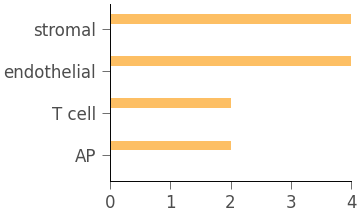

In [38]:
T_CELL_MARKERS = [
    "CD3D", "CD3E", "CD3G", "CD8A", "CD8B", "CD4",
    "FOXP3", "IL7R", "CCR7", "TCF7", "LEF1", "SELL",
    "TIGIT", "PDCD1", "LAG3", "HAVCR2", "TOX",
]

NK_CELL_MARKERS = [
    "NCAM1", "GNLY", "GZMB", "GZMA", "GZMK", "PRF1",
    "NKG7", "KLRD1", "KLRB1", "KLRF1", "NCR1", "NCR3", "KLRG1",
]

B_CELL_MARKERS = [
    "CD79A", "CD79B", "MS4A1", "CD19", "CD22", "FCRL5",
    "CR2", "FCER2", "PAX5", "POU2AF1", "MZB1", "DERL3", "TNFRSF17",
]

STROMAL_AND_STRUCTURAL_MARKERS = [
    "COL1A1", "PECAM1", "COL4A1", "COL5A1", "COL6A3", "COL11A1",
    "FN1", "LAMB3", "LAMC2", "FBLN1", "TNC", "ACTA2", "FAP", "DES",
]

ENDOTHELIAL_MARKERS = [
    "VWF", "CDH5", "CLDN5", "PLVAP", "MMRN1", "MMRN2", "CLEC14A",
    "KDR", "TEK", "VEGFB", "VEGFA", "VEGFC", "ANGPT1", "ANGPT2", "NRP1",
]

EPITHELIAL_MARKERS = ["EPCAM", "CDH1", "MUC1", "MUC4"]

IMMUNE_REGULATION_MARKERS = [
    "HLA-DRA", "HLA-DRB1", "HLA-DPB1", "HLA-DMA", "HLA-DPA1", "HLA-DQA1",
    "CD276", "LGALS9", "PDCD1LG2", "XBP1",
]


def get_gene_groups_bc(genes):
    rows = []
    for gene in genes:
        if gene in T_CELL_MARKERS:
            group = "T cell"
        elif gene in NK_CELL_MARKERS:
            group = "NK cell"
        elif gene in B_CELL_MARKERS:
            group = "B cell"
        elif gene in STROMAL_AND_STRUCTURAL_MARKERS:
            group = "stromal"
        elif gene in ENDOTHELIAL_MARKERS:
            group = "endothelial"
        elif gene in EPITHELIAL_MARKERS:
            group = "epithelial"
        elif gene in IMMUNE_REGULATION_MARKERS:
            group = "AP"
        else:
            group = "other"
        rows.append({"feature_name": gene, "gene_group": group})
    return pd.DataFrame(rows)


_all_res = pd.concat([
    results_classic.assign(name_display="classic"),
    results_csde.assign(name_display="CSDE"),
    results_imputation.assign(name_display="imput."),
])

_gene_groups = get_gene_groups_bc(_all_res["gene_name"].unique())
_all_res = _all_res.merge(_gene_groups, left_on="gene_name", right_on="feature_name", how="left")
_all_res["is_de"] = _all_res["padj"] < PADJ_THRESHOLD

gp_counts = (
    _all_res.query("is_de")
    .assign(gene_group=lambda x: x["gene_group"].astype("category"))
    .groupby(["name_display", "gene_group"])
    .size()
    .to_frame("count")
    .reset_index()
    .query("gene_group != 'other'")
)

fig_gene_groups = (
    gg.ggplot(
        gp_counts,
        gg.aes(x="factor(gene_group)", y="count", fill="factor(name_display)"),
    )
    + gg.geom_col(width=0.7, position="dodge")
    + gg.scale_y_continuous(expand=(0, 0))
    + gg.scale_fill_manual(values=MODEL_COLORS_BC)
    + LEGEND
    + gg.theme(figure_size=(1.8, 1.08))
    + gg.labs(x="", y="")
    + gg.coord_flip()
)
fig_gene_groups.save(f"{results_dir}/breast_cancer_gene_groups.svg", bbox_inches="tight")
fig_gene_groups
